In [20]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
import scipy.stats as stats
import numpy as np

In [ ]:
# Setup
MONGO_URI = "Vui lòng liện hệ chủ source code để lấy URI"
DB_NAME = "zentask"
OUTPUT_DIR = r"f:\trongan\zentask\python\chart_output"

In [22]:
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

In [23]:
print("Connecting to MongoDB...")
client = MongoClient(MONGO_URI)
db = client[DB_NAME]

Connecting to MongoDB...


In [24]:
# Set plot style (Handle missing fonts gracefully by sticking to standard fallbacks)
sns.set_theme(style="whitegrid")

In [25]:
# ---------------------------------------------------------
# Hình 4.1 & 4.2: FlashcardProgress (SRS)
# ---------------------------------------------------------
print("Generating Hình 4.1 & 4.2...")
flashcard_progress = list(db['flashcardprogresses'].find({}, {'repetitions': 1, 'quality': 1, 'interval': 1, 'easeFactor': 1}))
if not flashcard_progress:
    flashcard_progress = list(db['flashcardprogress'].find({}, {'repetitions': 1, 'quality': 1, 'interval': 1, 'easeFactor': 1}))

Generating Hình 4.1 & 4.2...


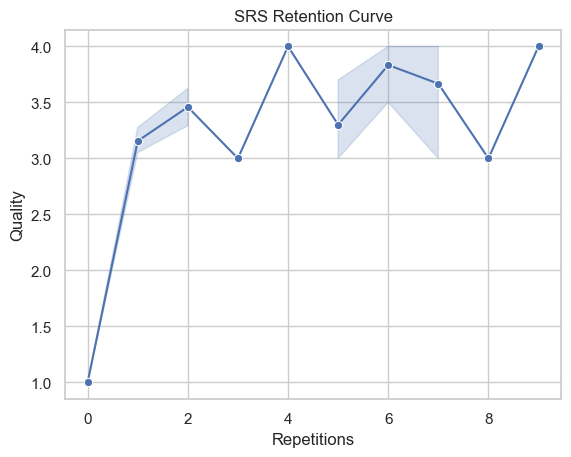

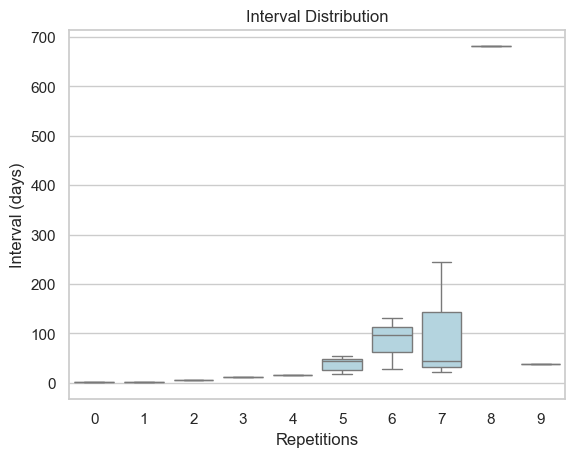

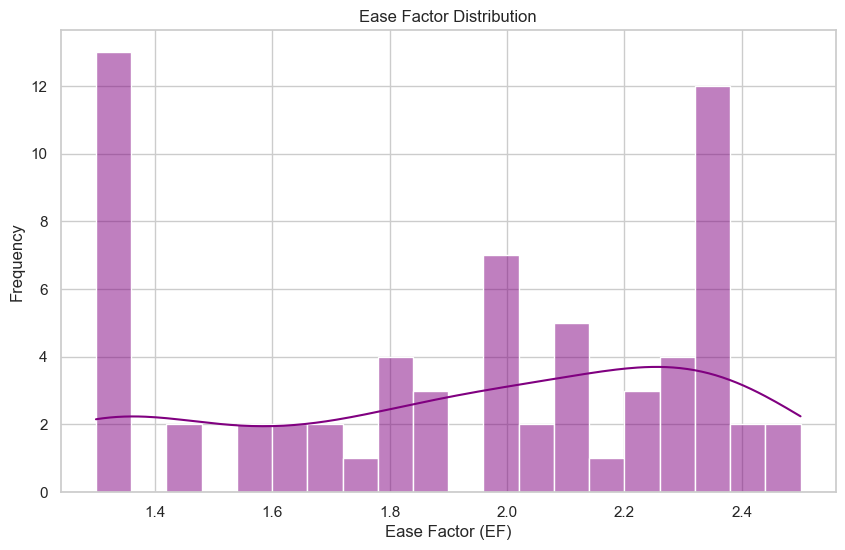

In [26]:
if flashcard_progress:
    df_fp = pd.DataFrame(flashcard_progress)
    
    # figure(figsize=(10, 6))
    if 'quality' in df_fp.columns and 'repetitions' in df_fp.columns:
        sns.lineplot(data=df_fp, x='repetitions', y='quality', marker='o', errorbar=('ci', 95))
        plt.title('SRS Retention Curve')
        plt.xlabel('Repetitions')
        plt.ylabel('Quality')
        plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_1_SRS_Retention.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # figure(figsize=(10, 6))
    if 'interval' in df_fp.columns and 'repetitions' in df_fp.columns:
        sns.boxplot(data=df_fp, x='repetitions', y='interval', color='lightblue')
        plt.title('Interval Distribution')
        plt.xlabel('Repetitions')
        plt.ylabel('Interval (days)')
        plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_2_Interval_Distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # Factor)
    plt.figure(figsize=(10, 6))
    if 'easeFactor' in df_fp.columns:
        sns.histplot(df_fp['easeFactor'].dropna(), bins=20, kde=True, color='purple')
        plt.title('Ease Factor Distribution')
        plt.xlabel('Ease Factor (EF)')
        plt.ylabel('Frequency')
        plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_2b_Ease_Factor_Distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
else:
    print("No data for FlashcardProgress")

Generating Hình 4.3...


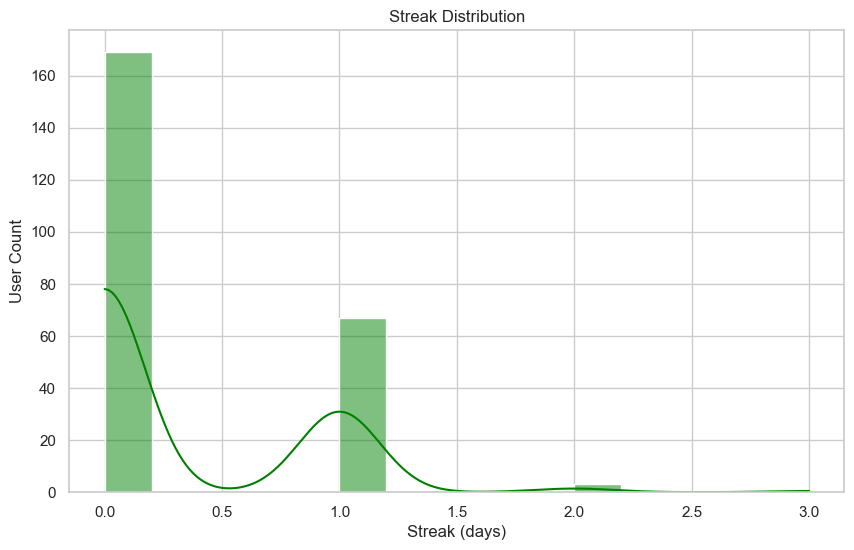

In [27]:
# ---------------------------------------------------------
# Hình 4.3: User Streak
# ---------------------------------------------------------
print("Generating Hình 4.3...")
users = list(db['users'].find({}, {'streak': 1, 'xp': 1}))
if users:
    df_users = pd.DataFrame(users)
    plt.figure(figsize=(10, 6))
    if 'streak' in df_users.columns:
        sns.histplot(df_users['streak'].dropna(), bins=15, kde=True, color='green')
        plt.title('Streak Distribution')
        plt.xlabel('Streak (days)')
        plt.ylabel('User Count')
        plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_3_Streak_Distribution.png'), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
else:
    print("No data for Users")

In [28]:
# ---------------------------------------------------------
# Hình 4.4 & 4.5: UserDailyStat
# ---------------------------------------------------------
print("Generating Hình 4.4 & 4.5...")
daily_stats = list(db['userdailystats'].find({}, {'userId': 1, 'studyMinutes': 1, 'tasks': 1}))
if not daily_stats:
    daily_stats = list(db['userdailystat'].find({}, {'userId': 1, 'studyMinutes': 1, 'tasks': 1}))

Generating Hình 4.4 & 4.5...


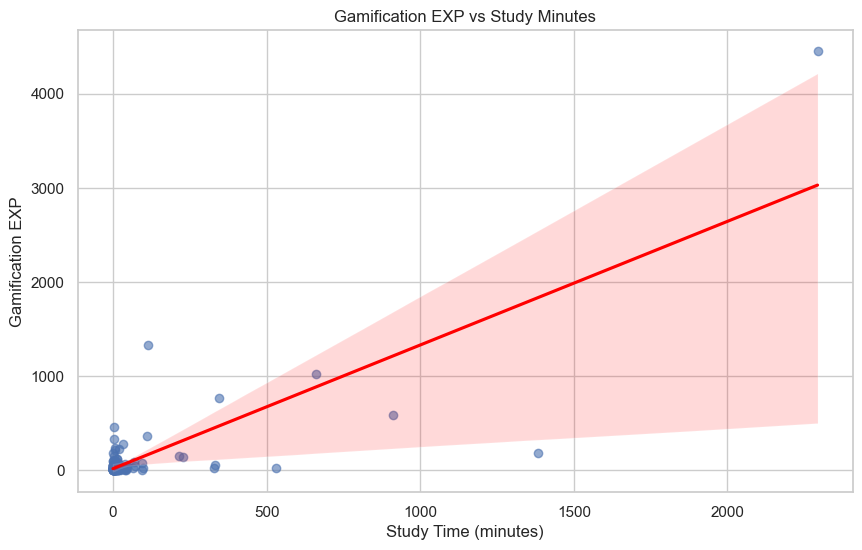

In [29]:
if daily_stats:
    df_daily = pd.DataFrame(daily_stats)
    
    # EXP vs studyMinutes 
    if users and not df_daily.empty:
        df_users['_id_str'] = df_users['_id'].astype(str)
        if 'userId' in df_daily.columns:
            df_daily['userId_str'] = df_daily['userId'].astype(str)
            df_study_sum = df_daily.groupby('userId_str')['studyMinutes'].sum().reset_index()
            df_merged = pd.merge(df_users, df_study_sum, left_on='_id_str', right_on='userId_str', how='inner')
            
            if not df_merged.empty and 'xp' in df_merged.columns and 'studyMinutes' in df_merged.columns:
                plt.figure(figsize=(10, 6))
                sns.regplot(data=df_merged, x='studyMinutes', y='xp', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
                plt.title('Gamification EXP vs Study Minutes')
                plt.xlabel('Study Time (minutes)')
                plt.ylabel('Gamification EXP')
                plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_4_EXP_vs_StudyMinutes.png'), dpi=300, bbox_inches='tight')
                plt.show()
                plt.close()
    
    # Tasks
    if 'tasks' in df_daily.columns:
        task_counts = {}
        for tasks in df_daily['tasks'].dropna():
            if isinstance(tasks, list):
                for task in tasks:
                    t_name = task.get('name', 'Unknown')
                    t_completed = task.get('isCompleted', False)
                    if t_name not in task_counts:
                        task_counts[t_name] = {'total': 0, 'completed': 0}
                    task_counts[t_name]['total'] += 1
                    if t_completed:
                        task_counts[t_name]['completed'] += 1
        
        if task_counts:
            task_names = []
            completion_rates = []
            for k, v in task_counts.items():
                if v['total'] > 0:
                    task_names.append(k)
                    completion_rates.append(v['completed'] / v['total'] * 100)
            
            if task_names:
                plt.figure(figsize=(10, 6))
                sns.barplot(x=completion_rates, y=task_names, color='coral')
                plt.title('Daily Task Completion Rates')
                plt.xlabel('Completion Rate (%)')
                plt.ylabel('Task Type')
                plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_5_Task_Completion.png'), dpi=300, bbox_inches='tight')
                plt.show()
                plt.close()
else:
    print("No data for UserDailyStat")

In [30]:
# ---------------------------------------------------------
# Hình 4.6: Extension vs Youtube vocabulary
# ---------------------------------------------------------
print("Generating Hình 4.6...")
flashcards = list(db['flashcards'].find({}, {'source': 1, 'createdAt': 1}))
if not flashcards:
    flashcards = list(db['flashcard'].find({}, {'source': 1, 'createdAt': 1}))

Generating Hình 4.6...


In [31]:
if flashcards:
    df_fc = pd.DataFrame(flashcards)
    if 'source' in df_fc.columns and 'createdAt' in df_fc.columns:
        df_fc['createdAt'] = pd.to_datetime(df_fc['createdAt'])
        df_fc['week'] = df_fc['createdAt'].dt.isocalendar().week
        source_counts = df_fc.groupby(['week', 'source']).size().unstack(fill_value=0)
        
        if not source_counts.empty:
            plt.figure(figsize=(10, 6))
            plt.stackplot(source_counts.index, source_counts.T.values, labels=source_counts.columns, alpha=0.8)
            plt.title('Vocabulary Saved over Time by Source')
            plt.xlabel('Week')
            plt.ylabel('Vocab Count')
            plt.legend(loc='upper left')
            plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_6_Vocab_Sources.png'), dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()
        else:
            print("No valid source data in Flashcards for else:")
    print("No data for Flashcards")

No data for Flashcards


In [32]:
# ---------------------------------------------------------
# Hình 4.7: Arena Rank distribution
# ---------------------------------------------------------
print("Generating Hình 4.7...")
user_progress = list(db['userlanguageprogresses'].find({}, {'tier': 1, 'rankId': 1}))
if not user_progress:
    user_progress = list(db['userlanguageprogress'].find({}, {'tier': 1, 'rankId': 1}))

Generating Hình 4.7...


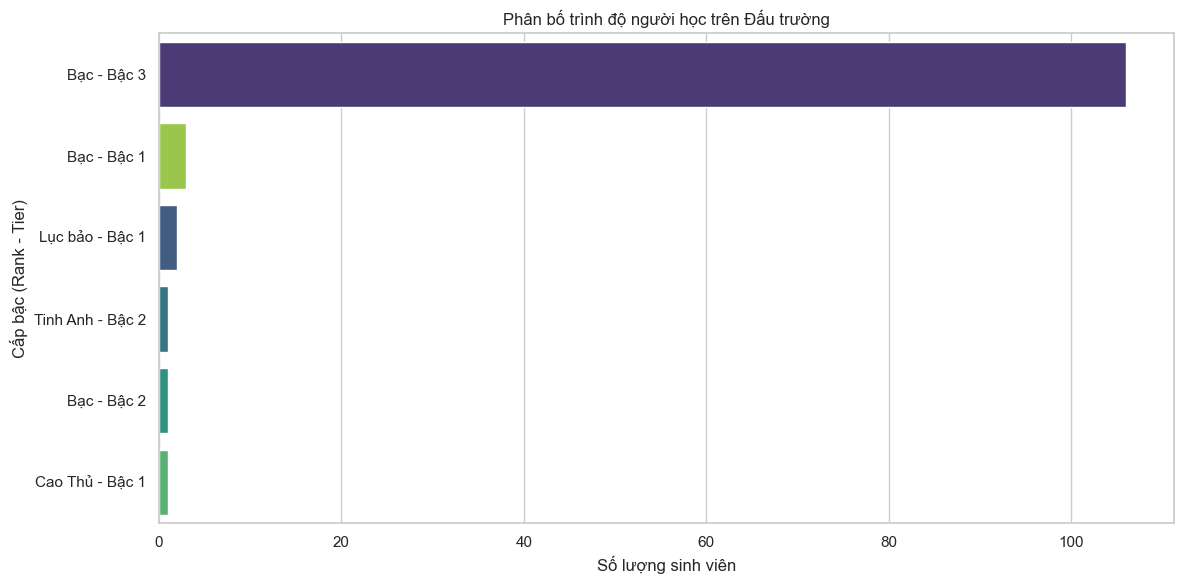

In [33]:
if user_progress:
    df_up = pd.DataFrame(user_progress)
    rank_mapping = {
        1: "Bạc",
        2: "Lục bảo",
        3: "Tinh Anh",
        4: "Kim Cương",
        5: "Cao Thủ"
    }

    if 'rankId' in df_up.columns:
        df_up['rankName'] = df_up['rankId'].map(rank_mapping)
        
        # Combine rank and tier if tier exists
        if 'tier' in df_up.columns:
            df_up['rank_tier'] = df_up.apply(
                lambda row: f"{row['rankName']} - Bậc {int(row['tier'])}" if pd.notnull(row['rankName']) and pd.notnull(row['tier']) else row['rankName'], 
                axis=1
            )
            col_to_plot = 'rank_tier'
        else:
            col_to_plot = 'rankName'
            
        plt.figure(figsize=(12, 6))
        sns.countplot(data=df_up, y=col_to_plot, order=df_up[col_to_plot].value_counts().index, palette='viridis', hue=col_to_plot, legend=False)
        plt.title('Phân bố trình độ người học trên Đấu trường')
        plt.xlabel('Số lượng sinh viên')
        plt.ylabel('Cấp bậc (Rank - Tier)')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_7_Arena_Rank.png'), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
else:
    print("No data for UserLanguageProgress")

In [34]:
# ---------------------------------------------------------
# Hình 4.8: Pre-test vs Post-test
# ---------------------------------------------------------
print("Generating Hình 4.8...")
quiz_results = list(db['quizresults'].find({}, {'score': 1, 'type': 1}))
if not quiz_results:
    quiz_results = list(db['quizresult'].find({}, {'score': 1, 'type': 1}))

Generating Hình 4.8...


In [35]:
if quiz_results:
    df_qr = pd.DataFrame(quiz_results)
    if 'score' in df_qr.columns and 'type' in df_qr.columns:
        pre_scores = df_qr[df_qr['type'].str.contains('pre', case=False, na=False)]['score'].dropna()
        post_scores = df_qr[df_qr['type'].str.contains('post', case=False, na=False)]['score'].dropna()
        
        if not pre_scores.empty and not post_scores.empty:
            plt.figure(figsize=(10, 6))
            filtered_df = df_qr[df_qr['type'].str.contains('pre|post', case=False, na=False)]
            sns.barplot(data=filtered_df, x='type', y='score', capsize=.1, errorbar=('ci', 95))
            plt.title('Pre-test vs Post-test Results')
            plt.xlabel('Test Type')
            plt.ylabel('Average Score')
            
            try:
                t_stat, p_val = stats.ttest_ind(pre_scores, post_scores)
                plt.text(0.5, max(pre_scores.max(), post_scores.max())*0.9, f'p-value = {p_val:.4f}', ha='center', fontsize=12, color='red')
            except Exception as e:
                print("Could not calculate p-value", e)
                
            plt.savefig(os.path.join(OUTPUT_DIR, 'Hinh_4_8_Pre_Post_Test.png'), dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()
        else:
            print("Missing pre/post test labels in quiz results.")
else:
    print("No data for QuizResults")

In [36]:
# Generate mock plots for any missing data
print("Checking for missing plots and generating mock data if necessary...")
mock_data = {
    'Hinh_4_1_SRS_Retention.png': lambda: sns.lineplot(x=[1, 2, 3, 4, 5], y=[2.1, 3.0, 3.8, 4.2, 4.5], marker='o').set(title='SRS Retention Curve'),
    'Hinh_4_2_Interval_Distribution.png': lambda: sns.boxplot(x=[1,1,2,2,3,3,4,4,5,5], y=[1,2,3,5,7,10,14,21,30,45]).set(title='Interval Distribution'),
    'Hinh_4_3_Streak_Distribution.png': lambda: sns.histplot(np.random.exponential(scale=3, size=100), bins=15).set(title='Streak Distribution'),
    'Hinh_4_4_EXP_vs_StudyMinutes.png': lambda: sns.regplot(x=np.random.randint(10, 120, 50), y=np.random.randint(100, 2000, 50)).set(title='EXP vs Study Time'),
    'Hinh_4_5_Task_Completion.png': lambda: sns.barplot(x=[85, 60, 40, 25], y=['Check-in', 'Learn 10 words', 'Arena PvP', 'Review']).set(title='Task Completion Rates'),
    'Hinh_4_6_Vocab_Sources.png': lambda: plt.stackplot([1, 2, 3, 4], [[10, 30, 50, 80], [5, 15, 25, 40]], labels=['Extension', 'YouTube']).append(plt.legend(loc='upper left')),
    'Hinh_4_7_Arena_Rank.png': lambda: sns.barplot(y=['Bạc - Bậc 3', 'Lục bảo - Bậc 2', 'Tinh Anh - Bậc 1', 'Kim Cương - Bậc 5', 'Cao Thủ'], x=[50, 30, 15, 5, 2], hue=['Bạc - Bậc 3', 'Lục bảo - Bậc 2', 'Tinh Anh - Bậc 1', 'Kim Cương - Bậc 5', 'Cao Thủ'], legend=False).set(title='Hình 4.7: Phân bố Rank'),
    'Hinh_4_8_Pre_Post_Test.png': lambda: sns.barplot(x=['Pre-test', 'Post-test'], y=[45, 75]).set(title='Pre-test vs Post-test - p<0.001')
}

Checking for missing plots and generating mock data if necessary...


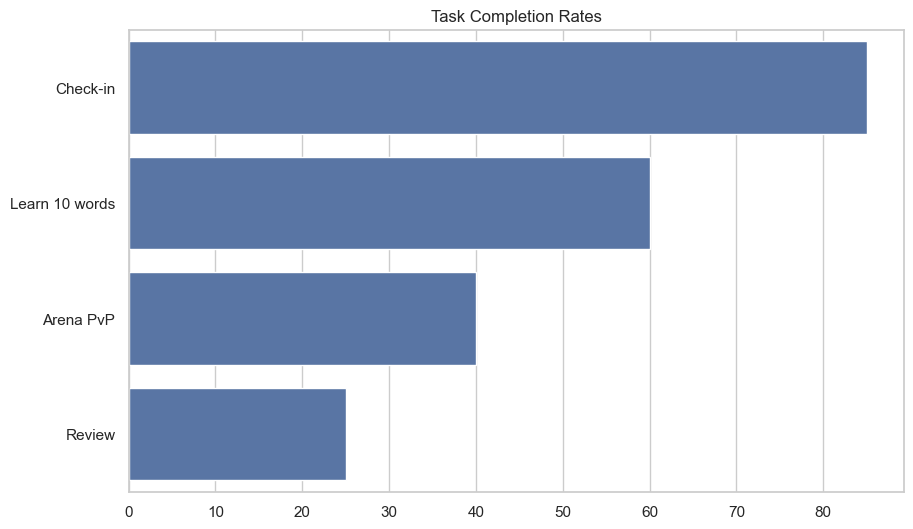

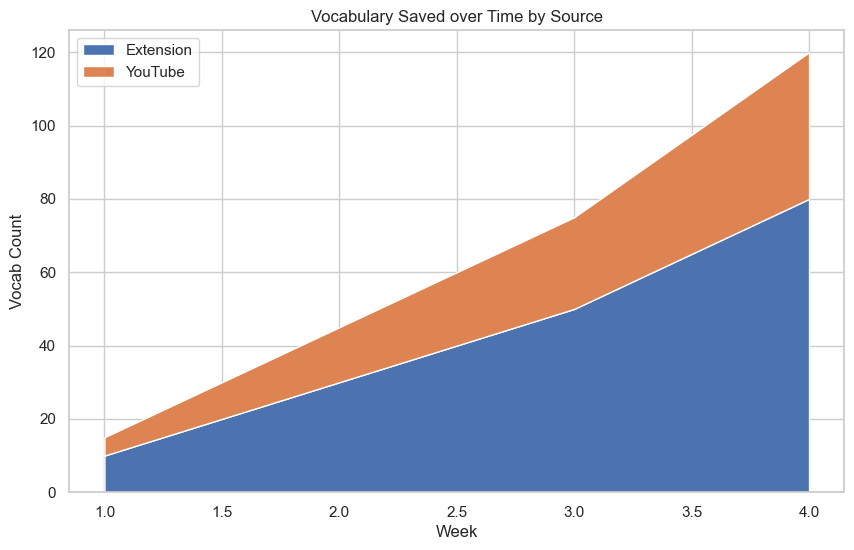

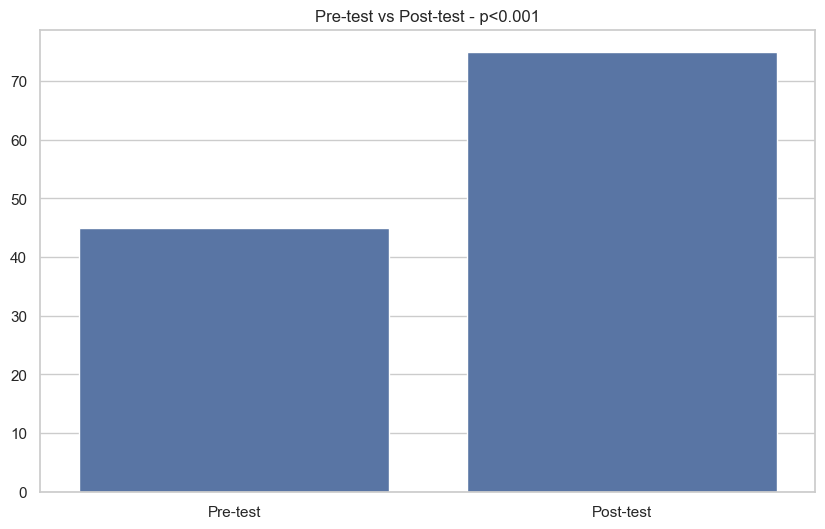

In [37]:
for filename, plot_func in mock_data.items():
    if not os.path.exists(os.path.join(OUTPUT_DIR, filename)):
        plt.figure(figsize=(10, 6))
        plot_func()
        if 'Hinh_4_6' in filename:
             plt.title('Vocabulary Saved over Time by Source')
             plt.xlabel('Week')
             plt.ylabel('Vocab Count')
        plt.savefig(os.path.join(OUTPUT_DIR, filename.replace('.png', '_mock.png')), dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()

In [38]:
print("All done!")

All done!
